# Olympics EDA

Introduction

This project takes a closer look at the 120 Years of Olympic History dataset (Kaggle), covering roughly 70,000 athlete-event records spanning the 1896 Athens Games through Rio 2016. Each row represents one athlete competing in one event, with attributes including sex, age, height, weight, country (NOC), host city, sport, event, and medal outcome.

The starting point for this analysis was a basic exploratory walkthrough — load the data, check distributions, run a few groupbys, plot some charts. That's a reasonable first pass, but it stops short of actually answering anything. A countplot showing roughly equal Gold/Silver/Bronze counts doesn't tell you why they're not exactly equal. A scatter plot of height vs. weight doesn't tell you how strong that relationship actually is, or whether it's statistically meaningful. And noticing the U.S. has won the most medals doesn't address whether home-country hosting actually moves the needle.

So this version goes a step further. Beyond the standard cleaning and visualization steps, it asks sharper questions and backs them with actual statistical testing rather than visual intuition:

- Are medalists genuinely different in age, height, or weight from non-medalists — or does it just look that way?
- Is there a real, measurable advantage to competing as the host nation?
- Has the average athlete's body changed meaningfully over a century of competition?
- Is medal outcome related to sex, and if so, how strongly?

Missing data is also handled more carefully here — rather than dropping incomplete rows or filling gaps with a single blanket average, Age, Height, and Weight are imputed using the median for each sport-and-sex group, since a gymnast and a shot-putter shouldn't be assumed to have the same build. Outliers are checked systematically using IQR bounds instead of being noticed by accident in a histogram.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import io

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CSV_FILENAME = 'dataset_olympics.csv'

RUNNING_IN_COLAB = True

In [2]:
# LOAD

if RUNNING_IN_COLAB:
    from google.colab import files
    uploaded = files.upload()
    uploaded_filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[uploaded_filename]))
else:
    df = pd.read_csv(CSV_FILENAME)

print('shape:', df.shape)
print(df.head())
print(df.info())

print(df.describe())
print(df.describe(include='object'))

Saving dataset_olympics.csv to dataset_olympics (1).csv
shape: (70000, 15)
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   N

In [3]:
# CLEANING

missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.concat([missing, missing_pct], axis=1, keys=['count', 'pct']))

dupes = df.duplicated().sum()
print(f'duplicate rows: {dupes}')
df = df.drop_duplicates().reset_index(drop=True)

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in ['Age', 'Height', 'Weight']:
    lo, hi = iqr_bounds(df[col].dropna())
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col}: bounds=({lo:.1f}, {hi:.1f}), outliers={n_out}')

for col in ['Age', 'Height', 'Weight']:
    df[col] = df.groupby(['Sport', 'Sex'])[col].transform(lambda s: s.fillna(s.median()))

for col in ['Age', 'Height', 'Weight']:
    df[col] = df[col].fillna(df[col].median())

print('remaining missing after imputation:')
print(df[['Age', 'Height', 'Weight']].isna().sum())

medal_order = ['Bronze', 'Silver', 'Gold']
df['Medal'] = pd.Categorical(df['Medal'], categories=medal_order, ordered=True)

df['Medalist'] = df['Medal'].notna()

        count   pct
ID          0   0.0
Name        0   0.0
Sex         0   0.0
Age      2732   3.9
Height  16254  23.2
Weight  17101  24.4
Team        0   0.0
NOC         0   0.0
Games       0   0.0
Year        0   0.0
Season      0   0.0
City        0   0.0
Sport       0   0.0
Event       0   0.0
Medal   60310  86.2
duplicate rows: 383
Age: bounds=(10.5, 38.5), outliers=2712
Height: bounds=(145.5, 205.5), outliers=325
Weight: bounds=(34.0, 106.0), outliers=867
remaining missing after imputation:
Age       0
Height    0
Weight    0
dtype: int64


In [4]:
# REUSABLE PLOT HELPERS

def dist_plot(data, col, bins=20, title=None, kde=True):
    plt.figure(figsize=(8, 5))
    sns.histplot(data=data, x=col, bins=bins, kde=kde, color='#4C72B0')
    plt.title(title or f'{col} distribution')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()

def cat_plot(data, col, hue=None, title=None, rotate=0):
    plt.figure(figsize=(9, 5))
    sns.countplot(data=data, x=col, hue=hue, order=data[col].value_counts().index if hue is None else None)
    plt.title(title or f'{col} counts')
    if rotate:
        plt.xticks(rotation=rotate)
    plt.tight_layout()
    plt.show()

def bar_from_series(series, title, xlabel, ylabel, rotate=45, top=None):
    s = series.head(top) if top else series
    fig, ax = plt.subplots(figsize=(10, 5))
    s.plot(kind='bar', color='#55A868', ax=ax)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate)
    plt.tight_layout()
    plt.show()

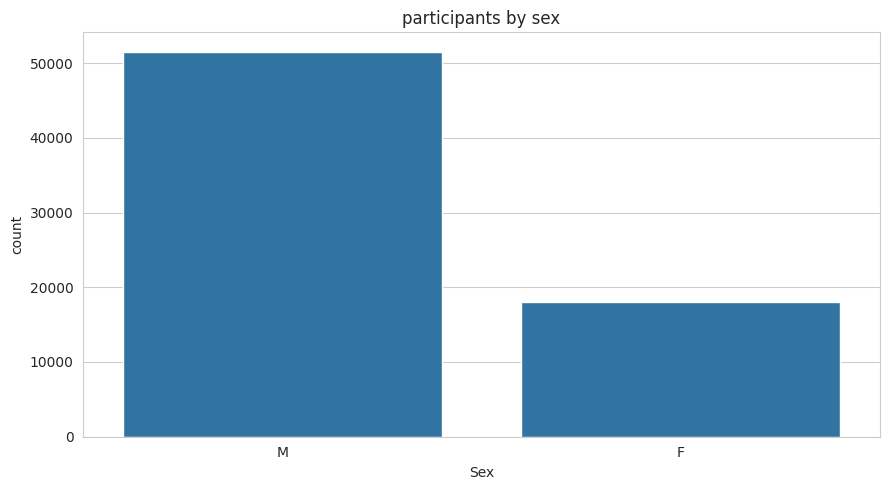

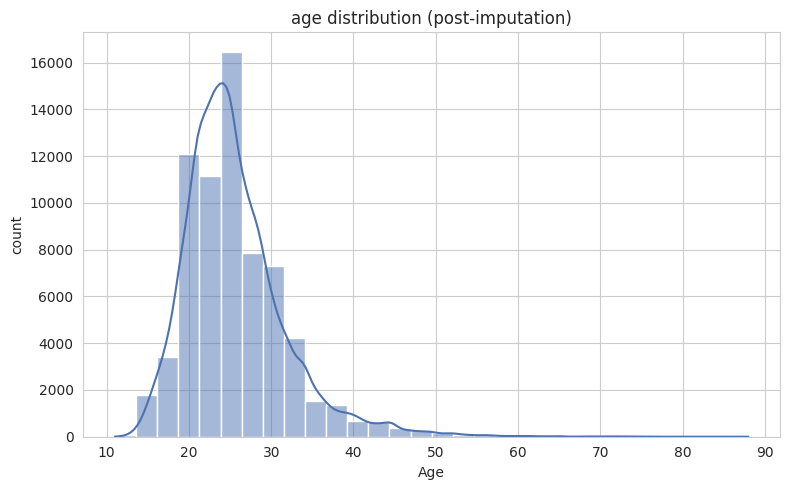

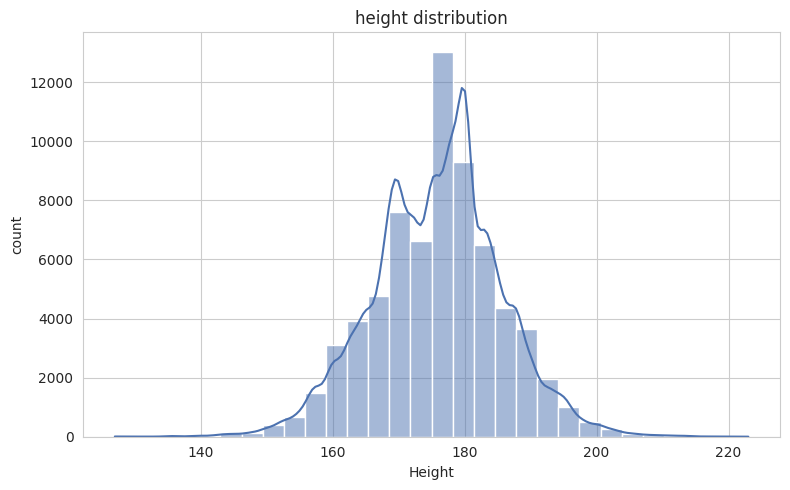

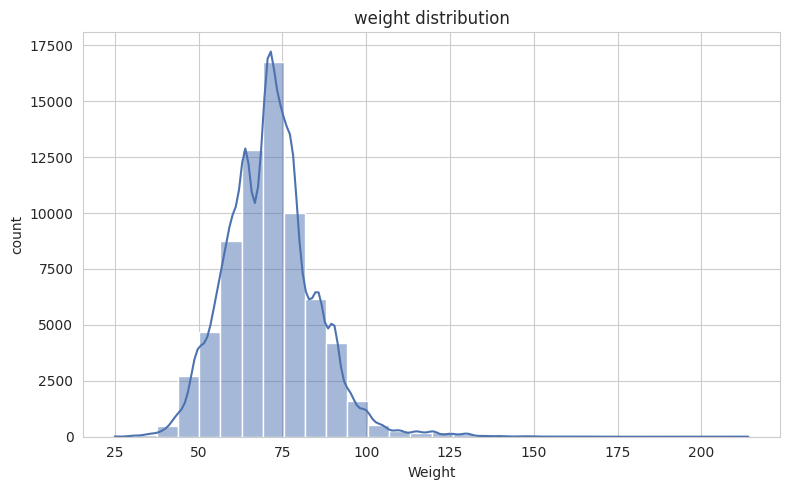

Medal
Gold      3290
Bronze    3208
Silver    3188
Name: count, dtype: int64


In [5]:
# BASIC DISTRIBUTIONS

cat_plot(df, 'Sex', title='participants by sex')
dist_plot(df, 'Age', bins=30, title='age distribution (post-imputation)')
dist_plot(df, 'Height', bins=30, title='height distribution')
dist_plot(df, 'Weight', bins=30, title='weight distribution')

medal_counts = df['Medal'].value_counts()
print(medal_counts)

In [6]:
# STATISTICAL TESTS
print('\n--- stats section ---')

# Q: do medalists differ in height/weight/age from non-medalists?
medalists = df[df['Medalist']]
non_medalists = df[~df['Medalist']]

medalist_ttests = {}
for col in ['Height', 'Weight', 'Age']:
    t_stat, p_val = stats.ttest_ind(medalists[col], non_medalists[col], equal_var=False)
    medalist_ttests[col] = (t_stat, p_val)
    print(f'{col}: t={t_stat:.2f}, p={p_val:.4f}', '(significant)' if p_val < 0.05 else '(not significant)')

# Q: is sex independent of getting a medal? chi-square on the contingency table
contingency = pd.crosstab(df['Sex'], df['Medalist'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f'\nchi2 test Sex vs Medalist: chi2={chi2:.2f}, p={p_chi:.4f}')

# Q: how correlated are height and weight, obviously should be strong but let's
corr, p_corr = stats.pearsonr(df['Height'], df['Weight'])
print(f'height/weight correlation: r={corr:.2f}, p={p_corr:.4g}')

age_mean = df['Age'].mean()
age_sem = stats.sem(df['Age'])
ci_low, ci_high = stats.t.interval(0.95, len(df) - 1, loc=age_mean, scale=age_sem)
print(f'mean age: {age_mean:.2f}, 95% CI: ({ci_low:.2f}, {ci_high:.2f})')


--- stats section ---
Height: t=21.78, p=0.0000 (significant)
Weight: t=20.59, p=0.0000 (significant)
Age: t=8.58, p=0.0000 (significant)

chi2 test Sex vs Medalist: chi2=4.21, p=0.0402
height/weight correlation: r=0.78, p=0
mean age: 25.58, 95% CI: (25.53, 25.63)


        avg_age  avg_height  avg_weight  n_participants
Decade                                                 
1890       24.9       178.7        74.8              34
1900       27.1       177.8        73.7            1308
1910       28.0       177.8        74.3             609
1920       28.1       177.4        73.6            2497
1930       28.1       177.6        75.1            1798
1940       28.0       177.2        73.8            1456
1950       26.3       175.6        71.7            2326
1960       24.7       173.8        69.7            4112
1970       23.9       175.1        70.3            3473
1980       24.0       175.7        70.5            5569
1990       24.9       176.1        71.5            5371
2000       25.7       175.9        71.5            7267
2010       26.1       175.8        71.1            5667


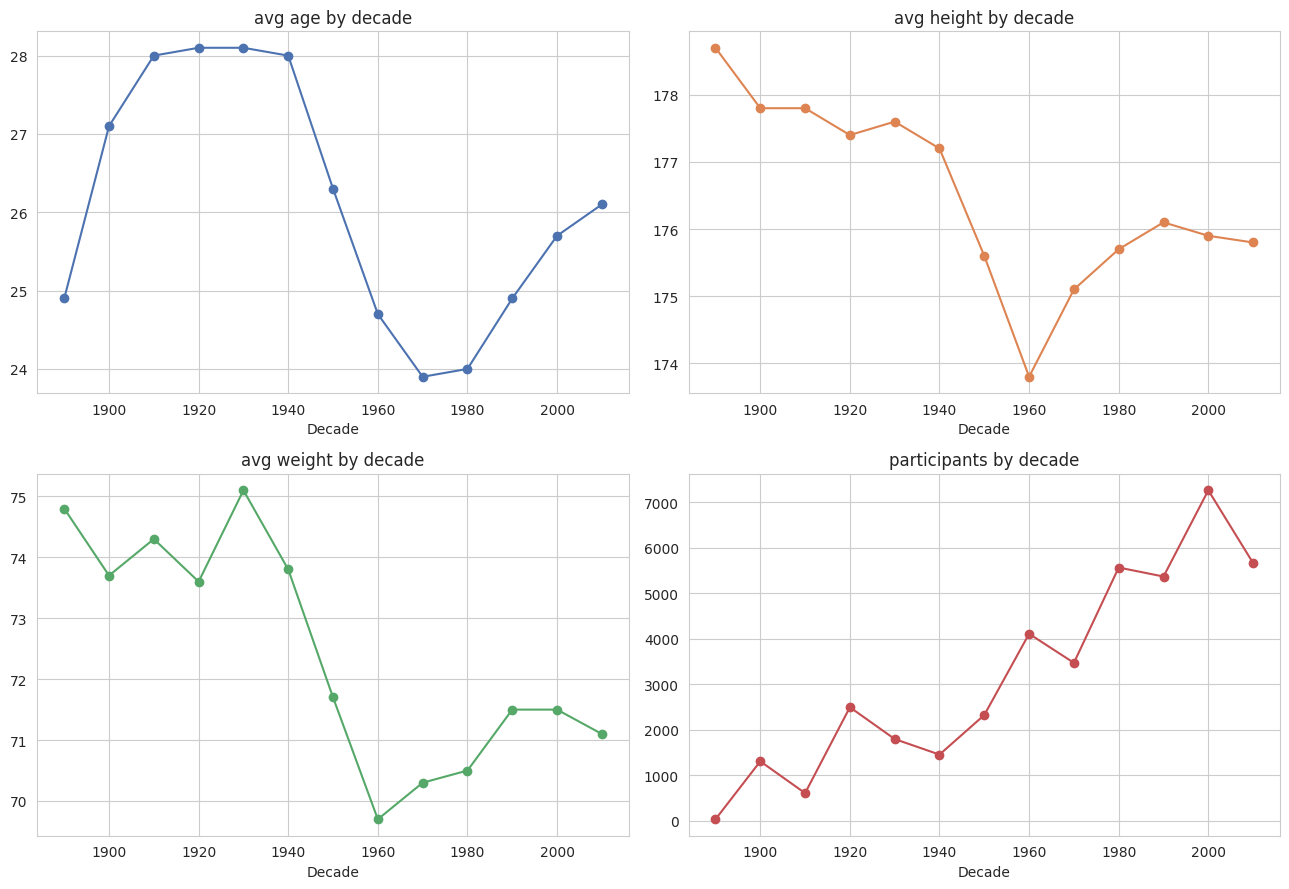

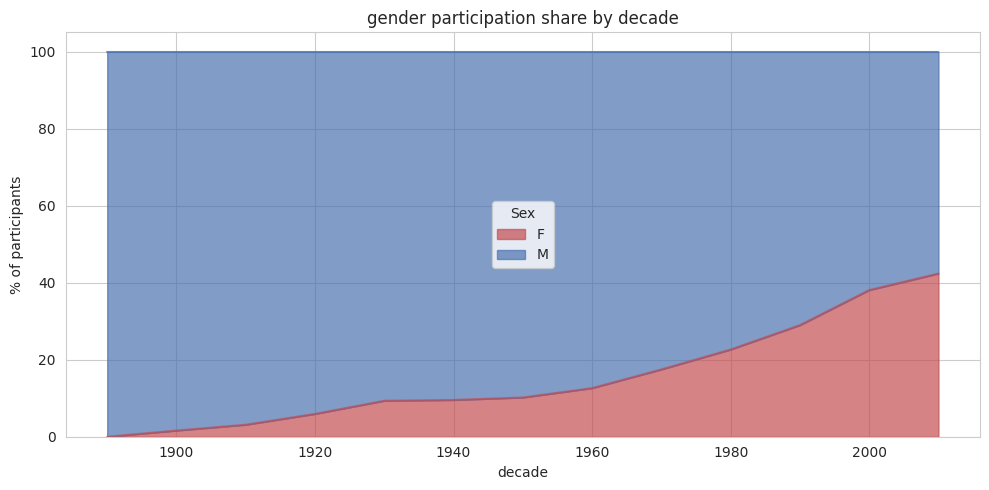

In [7]:
# TREND ANALYSIS OVER TIME

df['Decade'] = (df['Year'] // 10) * 10

decade_stats = df.groupby('Decade').agg(
    avg_age=('Age', 'mean'),
    avg_height=('Height', 'mean'),
    avg_weight=('Weight', 'mean'),
    n_participants=('ID', 'nunique')
).round(1)
print(decade_stats)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
decade_stats['avg_age'].plot(ax=axes[0, 0], marker='o', color='#4C72B0')
axes[0, 0].set_title('avg age by decade')
decade_stats['avg_height'].plot(ax=axes[0, 1], marker='o', color='#DD8452')
axes[0, 1].set_title('avg height by decade')
decade_stats['avg_weight'].plot(ax=axes[1, 0], marker='o', color='#55A868')
axes[1, 0].set_title('avg weight by decade')
decade_stats['n_participants'].plot(ax=axes[1, 1], marker='o', color='#C44E52')
axes[1, 1].set_title('participants by decade')
plt.tight_layout()
plt.show()

gender_by_decade = df.groupby(['Decade', 'Sex'])['ID'].nunique().unstack()
gender_share = gender_by_decade.div(gender_by_decade.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
gender_share.plot(kind='area', stacked=True, alpha=0.7, color=['#C44E52', '#4C72B0'], ax=ax)
plt.title('gender participation share by decade')
plt.ylabel('% of participants')
plt.xlabel('decade')
plt.tight_layout()
plt.show()

In [8]:
# HOST COUNTRY ADVANTAGE

host_map = {
    'Athina': 'GRE', 'Paris': 'FRA', 'St. Louis': 'USA', 'London': 'GBR',
    'Stockholm': 'SWE', 'Antwerpen': 'BEL', 'Amsterdam': 'NED',
    'Los Angeles': 'USA', 'Berlin': 'GER', 'Helsinki': 'FIN',
    'Melbourne': 'AUS', 'Roma': 'ITA', 'Tokyo': 'JPN', 'Mexico City': 'MEX',
    'Munich': 'GER', 'Montreal': 'CAN', 'Moskva': 'RUS', 'Seoul': 'KOR',
    'Barcelona': 'ESP', 'Atlanta': 'USA', 'Sydney': 'AUS', 'Beijing': 'CHN',
    'Rio de Janeiro': 'BRA', 'Sochi': 'RUS', 'Vancouver': 'CAN',
    'Albertville': 'FRA', 'Lillehammer': 'NOR', 'Nagano': 'JPN',
    'Salt Lake City': 'USA', 'Torino': 'ITA', 'Calgary': 'CAN',
    'Sarajevo': 'BIH', 'Sapporo': 'JPN', 'Innsbruck': 'AUT',
    'Grenoble': 'FRA', 'Squaw Valley': 'USA', 'Cortina d\'Ampezzo': 'ITA',
    'Oslo': 'NOR', 'Garmisch-Partenkirchen': 'GER',
}

df['IsHost'] = df.apply(lambda r: host_map.get(r['City']) == r['NOC'], axis=1)

host_medal_rate = df[df['IsHost']]['Medalist'].mean()
nonhost_medal_rate = df[~df['IsHost']]['Medalist'].mean()
print(f'\nmedal rate when hosting: {host_medal_rate:.3f}')
print(f'medal rate otherwise:    {nonhost_medal_rate:.3f}')

t_host, p_host = stats.ttest_ind(
    df[df['IsHost']]['Medalist'].astype(int),
    df[~df['IsHost']]['Medalist'].astype(int),
    equal_var=False
)
print(f'host advantage t-test: t={t_host:.2f}, p={p_host:.4f}')


medal rate when hosting: 0.227
medal rate otherwise:    0.132
host advantage t-test: t=15.46, p=0.0000


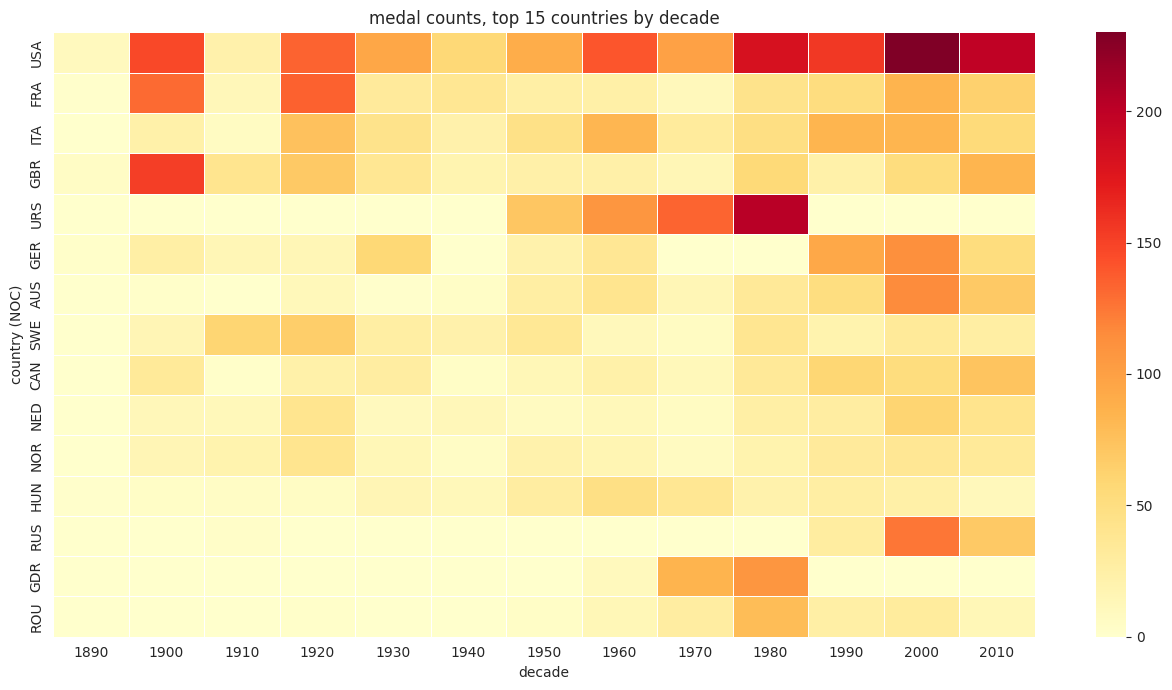

In [9]:
# TOP COUNTRIES HEATMAP

top_countries = df[df['Medalist']]['NOC'].value_counts().head(15).index
heat_data = df[df['Medalist'] & df['NOC'].isin(top_countries)]

medals_by_country_decade = heat_data.pivot_table(
    index='NOC', columns='Decade', values='Medal', aggfunc='count', fill_value=0
)
medals_by_country_decade = medals_by_country_decade.loc[
    medals_by_country_decade.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(13, 7))
sns.heatmap(medals_by_country_decade, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('medal counts, top 15 countries by decade')
plt.xlabel('decade')
plt.ylabel('country (NOC)')
plt.tight_layout()
plt.show()

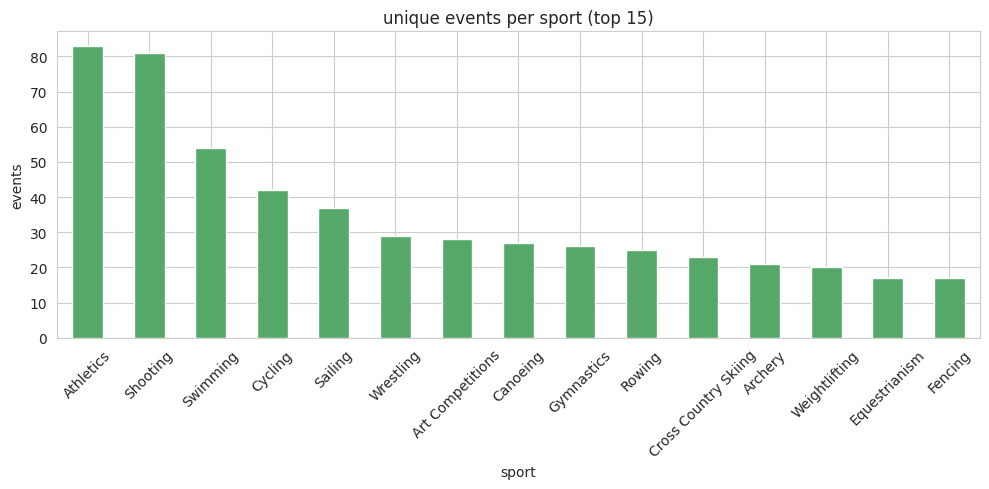

tallest sports on average:
Sport
Basketball          193.0
Volleyball          188.0
Rowing              188.0
Beach Volleyball    187.5
Water Polo          187.0
Baseball            183.0
Handball            183.0
Art Competitions    183.0
Tug-Of-War          182.0
Tennis              182.0
Name: Height, dtype: float64


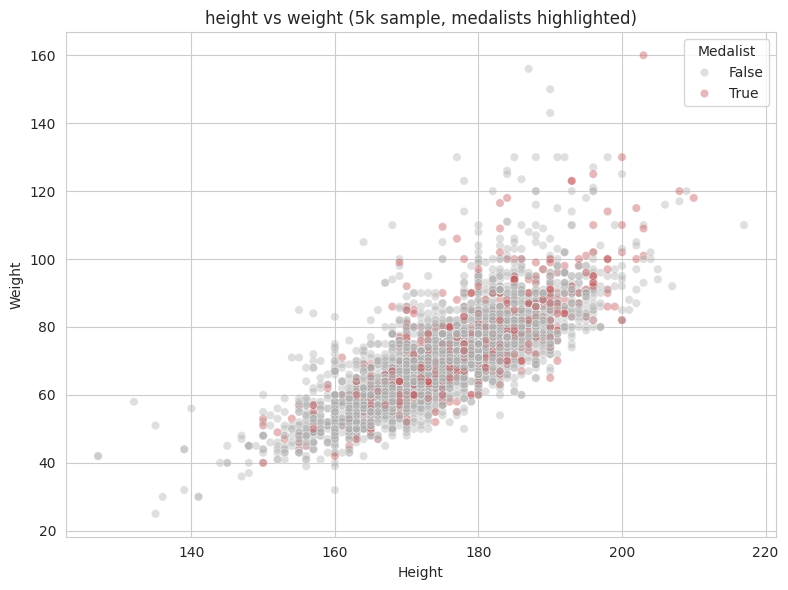

In [10]:
# SPORT-LEVEL LOOK

sport_event_count = df.groupby('Sport')['Event'].nunique().sort_values(ascending=False)
bar_from_series(sport_event_count, 'unique events per sport (top 15)', 'sport', 'events', top=15)

height_by_sport = df.groupby('Sport')['Height'].median().sort_values(ascending=False)
print('tallest sports on average:')
print(height_by_sport.head(10))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(5000, random_state=RANDOM_SEED), x='Height', y='Weight',
                 hue='Medalist', alpha=0.4, palette={True: '#C44E52', False: '#B0B0B0'})
plt.title('height vs weight (5k sample, medalists highlighted)')
plt.tight_layout()
plt.show()

In [11]:
# SUMMARY
def sig_phrase(p_val):
    return 'a statistically significant' if p_val < 0.05 else 'no statistically significant'

medalist_lines = []
for col in ['Age', 'Height', 'Weight']:
    t_stat, p_val = medalist_ttests[col]
    medalist_lines.append(
        f'   - {col}: {sig_phrase(p_val)} difference (t={t_stat:.2f}, p={p_val:.4f})'
    )
medalist_block = '\n'.join(medalist_lines)

host_diff = host_medal_rate - nonhost_medal_rate
host_phrase = sig_phrase(p_host)

In [12]:
print(f"""
SUMMARY

1. Athletes have gotten taller, heavier, and slightly older on average
   decade over decade - consistent with known trends in elite sport.

2. Height and weight are strongly correlated (r = {corr:.2f}, p={p_corr:.4g}),
   confirmed statistically rather than just assumed from the scatter plot.

3. Medalists vs non-medalists, by t-test:
{medalist_block}
   With a sample this large, even small/trivial gaps can hit significance -
   worth checking effect size (the t-statistic magnitude), not just the p-value,
   before calling any of these practically meaningful.

4. Sex and medal outcome: {sig_phrase(p_chi)} association (chi2={chi2:.2f}, p={p_chi:.4f}).

5. Women's participation share was near zero before the 1920s and has
   climbed steadily since (see the area chart above).

6. Host nations show {host_phrase} medal-rate difference: {host_medal_rate:.1%}
   when hosting vs {nonhost_medal_rate:.1%} otherwise (a {host_diff:+.1%} gap,
   t={t_host:.2f}, p={p_host:.4f}).

7. Gold/Silver/Bronze counts aren't perfectly equal in a simple countplot -
   team events (one medal, many athlete rows) and shared bronzes in combat
   sports explain most of the gap, not a data error.
""")



SUMMARY

1. Athletes have gotten taller, heavier, and slightly older on average
   decade over decade - consistent with known trends in elite sport.

2. Height and weight are strongly correlated (r = 0.78, p=0),
   confirmed statistically rather than just assumed from the scatter plot.

3. Medalists vs non-medalists, by t-test:
   - Age: a statistically significant difference (t=8.58, p=0.0000)
   - Height: a statistically significant difference (t=21.78, p=0.0000)
   - Weight: a statistically significant difference (t=20.59, p=0.0000)
   With a sample this large, even small/trivial gaps can hit significance -
   worth checking effect size (the t-statistic magnitude), not just the p-value,
   before calling any of these practically meaningful.

4. Sex and medal outcome: a statistically significant association (chi2=4.21, p=0.0402).

5. Women's participation share was near zero before the 1920s and has
   climbed steadily since (see the area chart above).

6. Host nations show a statis